# Clean up FNO pipeline

This is for the 2D Darcy problem on [0, 1]^2, with input permeability field discrete in {0, 1}.

In [ ]:
# Imports
import numpy as np
import sys

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern

import torch
from torch.utils.data import DataLoader

import neuralop
from neuralop.models import FNO
from neuralop import Trainer, LpLoss, H1Loss
from neuralop.training import AdamW
from neuralop.data.datasets import load_darcy_flow_small, DarcyDataset, TensorDataset
from neuralop.utils import count_model_params
from torch.nn import functional as F

import matplotlib.pyplot as plt
from McKean_Vlasov_data import load_dataset_mckean_vlasov, get_resolution

In [2]:
# ===== HYPERPARAMETERS =====

# === Data ===
data_n_train = 1_000
data_n_tests = [100, 50]
data_train_resolution = 64  # options: 16, 32, 64, 128, 421
data_test_resolutions = [64, 128]
data_batch_size = 32
data_test_batch_sizes = [32, 32]

# === Model ===
FNO_n_modes=(25, 25)  # these are the params which are saved. later change to (25,25). anyhow will have to vary for ablation study
FNO_in_channels=1
FNO_out_channels=1
FNO_hidden_channels=32  # Width of model. Documentation recommends 64, but 32 is sufficient for our purposes and much faster to train.
FNO_n_layers = 4  # Number of Fourier layers, the default
FNO_projection_channel_ratio=2
FNO_factorization="tucker"
FNO_rank=0.42
FNO_nonlinearity= F.gelu

# === Training ===
TRAIN_epochs = 150


In [3]:
def T_push(x, tau=-1, boundary=0):
    """A smooth approximation to the step function, which can be used to get a binary field from the GP sample while maintaining differentiability.
    See Akiyldiz for details.
    Combined with the option to get a hard threshold by setting tau=-1, based on the usual 3-12 normalisation.
    """
    if isinstance(x, np.ndarray):
        if tau == -1:
            return np.where(x < boundary, 3.0, 12.0)
        return 0.5 * np.tanh(tau * x) + 0.5
    else:  # torch tensor
        if tau == -1:
            return torch.where(x < boundary,
                               torch.tensor(3.0),
                               torch.tensor(12.0))
        return 0.5 * torch.tanh(tau * x) + 0.5

In [4]:
# Activate GPU (if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Import Data, McKean-Vlasov dataset
dataset = load_dataset_mckean_vlasov("mckean_vlasov_dataset.npz")


train_loader = DataLoader(
        dataset.train_db,
        batch_size=data_batch_size,
        num_workers=1,
        pin_memory=True,
        persistent_workers=False,
    )

test_loaders = {}
for res, test_bsize in zip(data_test_resolutions, data_test_batch_sizes):
    test_loaders[res] = DataLoader(
        dataset.test_dbs[res],
        batch_size=test_bsize,
        shuffle=False,
        num_workers=1,
        pin_memory=True,
        persistent_workers=False,
    )

data_processor = dataset.data_processor

print(type(dataset))
print(type(dataset.train_db))
print(type(dataset.test_dbs))
print(dataset.test_dbs)



Loading test db for resolution 64 with 100 samples 
Loading test db for resolution 128 with 50 samples 
<class 'neuralop.data.datasets.darcy.DarcyDataset'>
<class 'neuralop.data.datasets.tensor_dataset.TensorDataset'>
<class 'dict'>
{64: <neuralop.data.datasets.tensor_dataset.TensorDataset object at 0x77605ec65310>, 128: <neuralop.data.datasets.tensor_dataset.TensorDataset object at 0x77605ea53e50>}


In [45]:
# Instantiate Model
model = FNO(
    n_modes=FNO_n_modes,
    in_channels=FNO_in_channels,
    out_channels=FNO_out_channels,
    hidden_channels=FNO_hidden_channels,
    n_layers=FNO_n_layers,
    # projection_channel_ratio=FNO_projection_channel_ratio,
    factorization=FNO_factorization,
    non_linearity=FNO_nonlinearity,
    # rank=FNO_rank,
)

# NOTE: FNO takes in inputs of shape (batch_size, in_channels, height, width) and outputs the same shape.
# If you want to pass a single observation, you need to add batch and channel dimensions, e.g., x[0, 0].unsqueeze(0).unsqueeze(0) to get shape (1, 1, 16, 16).

model = model.to(device)

n_params = count_model_params(model)
print(f"\nOur model has {n_params} parameters.")
sys.stdout.flush()


# Scheduler and Loss

optimizer = AdamW(model.parameters(), lr=8e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

l2loss = LpLoss(d=2, p=2)
h1loss = H1Loss(d=2)

train_loss = h1loss
eval_losses = {"h1": h1loss, "l2": l2loss}



Our model has 2698289 parameters.


In [46]:
# Train model
# Creating the trainer
trainer = Trainer(
    model=model,
    n_epochs=TRAIN_epochs,
    device=device,
    data_processor=data_processor,
    wandb_log=False,
    eval_interval=5,
    use_distributed=False,
    verbose=True,
)

# DELETE checkpoints FOLDER BEFORE TRAINING FROM SCRATCH
# We train and save checkpoints
# Train from scratch
# trainer.train(
#     train_loader=train_loader,
#     test_loaders={},
#     optimizer=optimizer,
#     scheduler=scheduler,
#     regularizer=False,
#     training_loss=train_loss,
#     save_every=5,
#     save_dir="./checkpoints",
# )

torch.serialization.add_safe_globals([torch._C._nn.gelu])
torch.serialization.add_safe_globals([neuralop.layers.spectral_convolution.SpectralConv])

# Train from checkpoints
trainer.train(
    train_loader=train_loader,
    test_loaders={},
    optimizer=optimizer,
    scheduler=scheduler,
    regularizer=False,
    training_loss=train_loss,
    resume_from_dir="./checkpoints",
    save_dir="./checkpoints",
)

Trainer resuming from epoch 145
Training on 1000 samples
Testing on [] samples         on resolutions [].
[145] time=1.54, avg_loss=0.0472, train_err=1.4752
Eval: 


{'train_err': 1.4434143342077732,
 'avg_loss': 0.046189258694648745,
 'avg_lasso_loss': None,
 'epoch_train_time': 1.8031390110045322}

In [47]:
# === MCMC HYPERPARAMETERS ===
MCMC_delta = 0.0025  # can experiment later with adaptive delta, as in it gets smaller as the number of iterations increases.
MCMC_n_iterations = 20_000  # Most likely need it on the order of 100,000 to get good results, but we can test the code with fewer iterations first.
MCMC_tau = -1  # Smoothing parameter for the smooth threshold function. Higher values make it closer to a hard threshold, while lower values make it smoother. We can experiment with different values to see how it affects the results.


In [48]:
# MCMC helper functions

def log_likelihood(x: torch.Tensor, y: torch.Tensor, model, sigma=0.5275) -> torch.Tensor:
    """Inputs:
    - x: input tensor (location measurements of field θ)
    - y: observed output tensor (e.g., solution field u at locations x)
    - model: the trained FNO model that maps x to predicted y
    - sigma: standard deviation of the Gaussian likelihood
    Returns:
    - log-likelihood of observing y given x under the model's predictions"""
    # Ensure x and y are 4D tensors with shape (1, 1, height, width)
    # Ensure both x and y are on the same device as the model
    # x = x.to(device)
    # y = y.to(device)
    # Assuming Gaussian likelihood with fixed variance
    with torch.no_grad():
        forwards = model(x)
        mean = data_processor.out_normalizer.mean  # need to unnormalize the model outputs before comparing to y, since the model was trained on normalized data
        std = data_processor.out_normalizer.std
        forwards = forwards * std + mean
    forwards = forwards[0, 0]  # need .cpu() before .numpy()
    ll = -0.5 * torch.sum((y - forwards) ** 2).item() / sigma**2
    return ll


# Before the loop, build once:
_x_coords = np.linspace(0, 1, data_train_resolution)
_y_coords = np.linspace(0, 1, data_train_resolution)
_X, _Y = np.meshgrid(_x_coords, _y_coords)
_grid_points = np.column_stack([_X.ravel(), _Y.ravel()])
_gp = GaussianProcessRegressor(kernel=RBF(length_scale=0.3))

def sample_GP():
    sample = _gp.sample_y(_grid_points, n_samples=1, random_state=None)
    return sample.reshape(data_train_resolution, data_train_resolution)


# Before the loop
from sklearn.gaussian_process.kernels import Matern
# _kernel = RBF(length_scale=0.25)
_kernel = Matern(length_scale=0.3, nu=1) # nu=0.5 is even rougher
K_1d = _kernel(_x_coords.reshape(-1, 1))
K_1d += 1e-6 * np.eye(len(K_1d))
L_1d = np.linalg.cholesky(K_1d)


def sample_GP_kronecker():
    Z = np.random.randn(data_train_resolution, data_train_resolution)
    return L_1d @ Z @ L_1d.T


<class 'numpy.ndarray'>


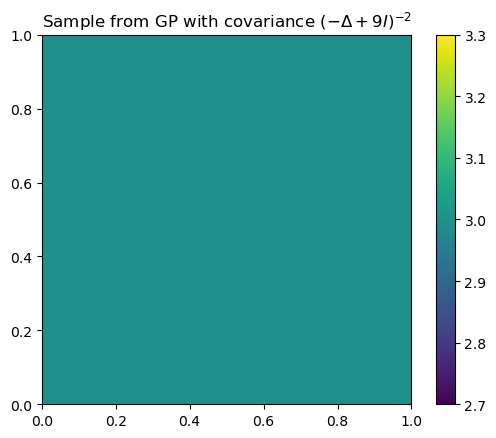

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 64    # physical grid resolution (unchanged)
M = 256   # oversampling factor — controls KL truncation level (M^2 terms)
L = 1.0


def sample_GP_operator(N=64, M=256):
    # Fine-grid wavenumbers — M^2 KL terms instead of N^2
    h_fine = 1 / M  # fine grid spacing for Fourier sampling
    kx = 2 * np.pi * np.fft.fftfreq(M, d=h_fine)
    ky = 2 * np.pi * np.fft.fftfreq(M, d=h_fine)

    KX, KY = np.meshgrid(kx, ky, indexing='ij')

    # Eigenvalues on fine Fourier grid
    A_eigs = KX**2 + KY**2 + 9.0
    Cov_eigs = 1.0 / (A_eigs**2)

    # Sample M^2 independent KL coefficients
    z = np.random.randn(M, M) + 1j * np.random.randn(M, M)
    u_hat = np.sqrt(Cov_eigs) * z

    # IFFT on fine grid
    u_fine = np.fft.ifft2(u_hat).real * M**2  # shape (M, M)

    # Subsample back to coarse N x N grid
    step = M // N
    u_coarse = u_fine[::step, ::step]  # shape (N, N)
    
    return u_coarse


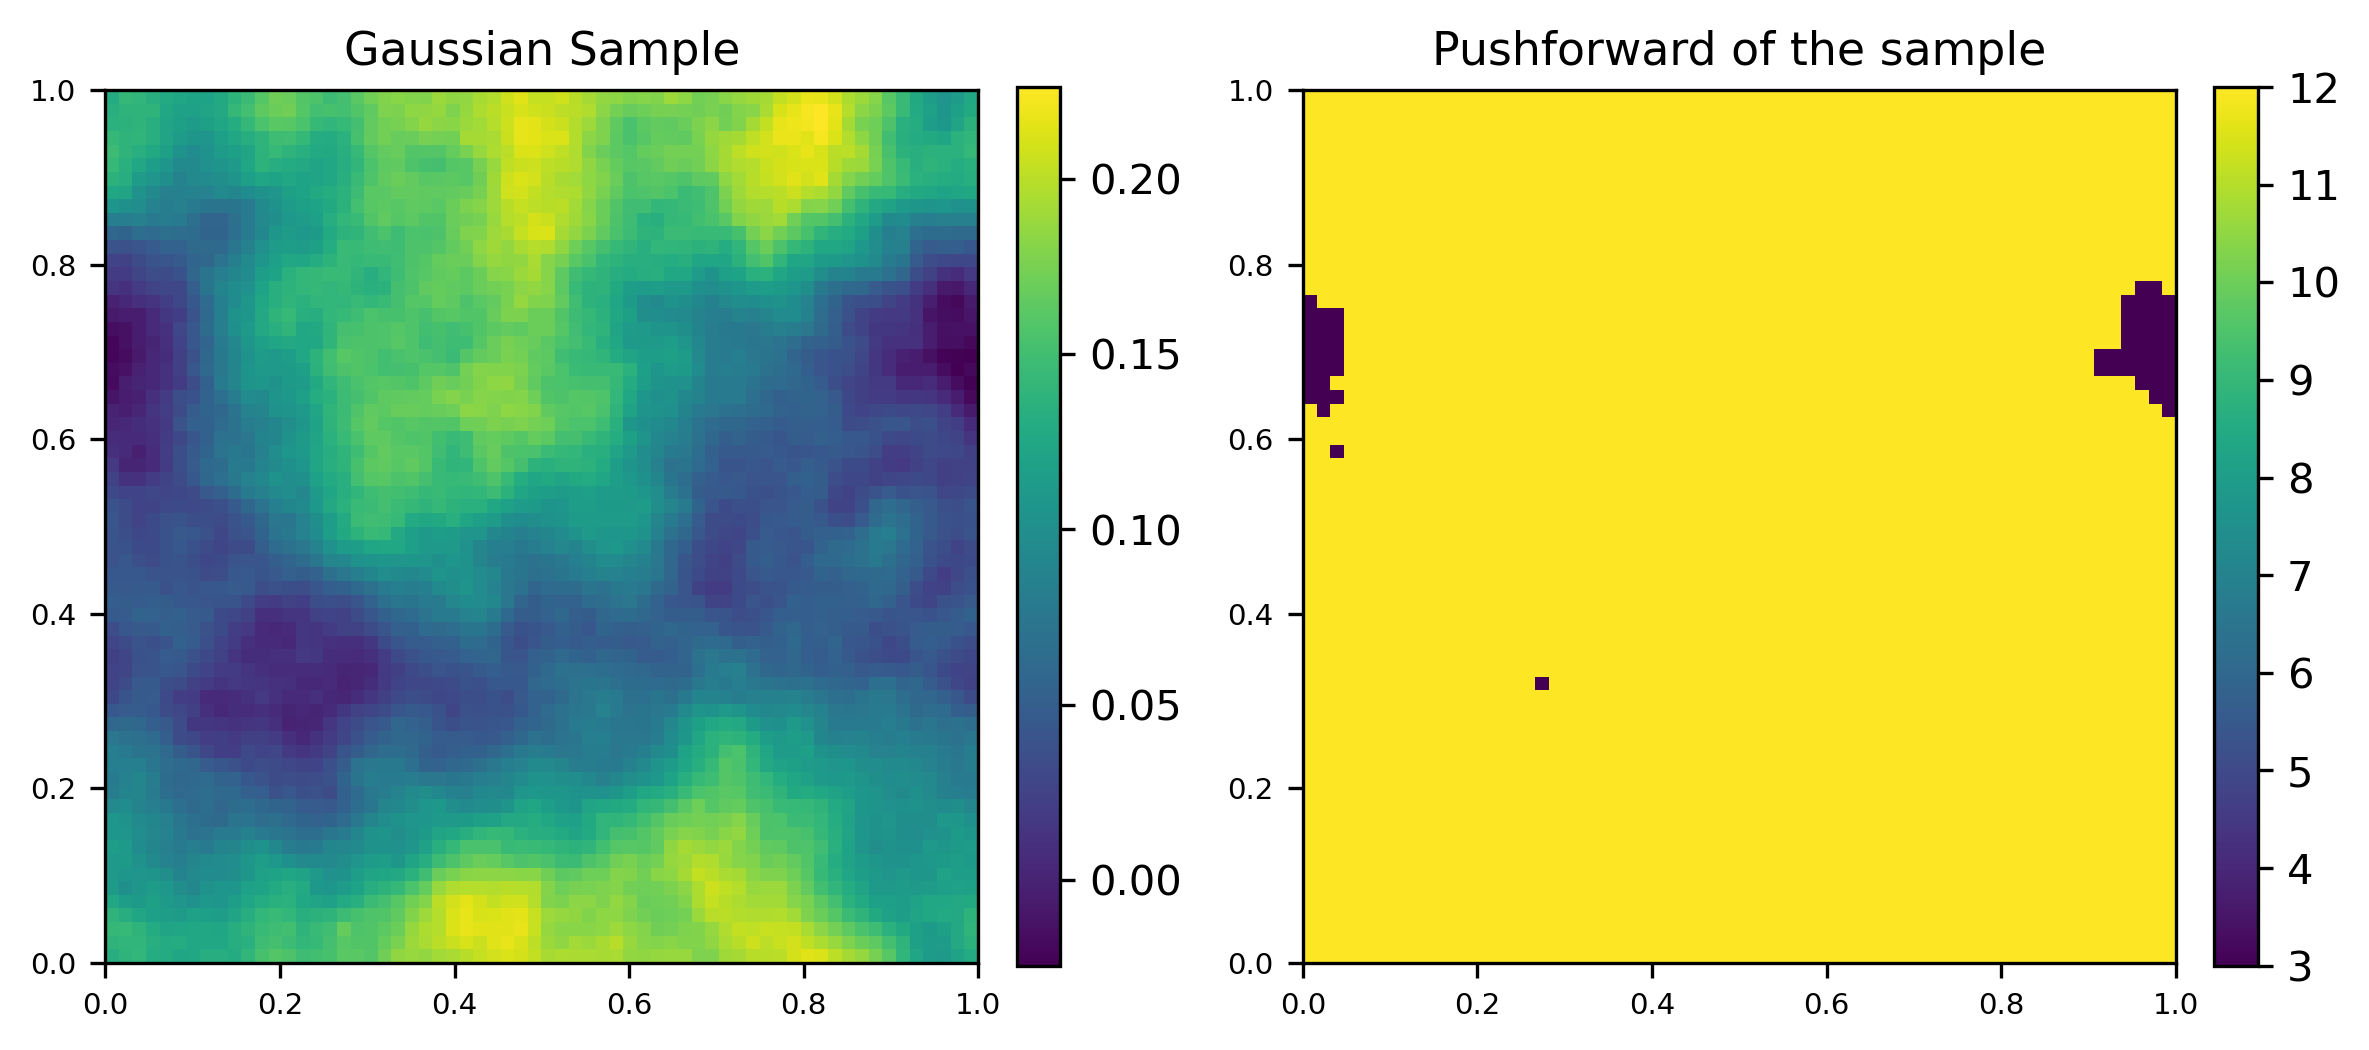

In [50]:
# FINAL REPORT: visualize the sample and its pushforward under T, to show how the smooth thresholding works

tf1 = sample_GP_operator(M=256)
tf2 = T_push(tf1, tau=-1)

fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=300)

for ax, tf, label in zip(axs, [tf1, tf2], ["Gaussian Sample", "Pushforward of the sample"]):
    ax.set_title(label, fontsize=11, loc='center', pad=6)
    im = ax.imshow(tf, extent=[0, 1, 0, 1], origin='lower',
                   vmin=tf.min(), vmax=tf.max())  # each plot autoscales to its own data
    ax.tick_params(labelsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
# plt.savefig('figures_for_report/sample_coeff_and_pushforward.png', bbox_inches='tight', dpi=300)
plt.show()

In [52]:
# Get true field from test set
true_field = dataset.test_dbs[data_train_resolution].x[0, 0].unsqueeze(0).unsqueeze(0)  # shape (1, 1, train_resolution, train_resolution)
true_observations = dataset.test_dbs[data_train_resolution].y[0, 0].unsqueeze(0).unsqueeze(0)  # shape (1, 1, train_resolution, train_resolution)
sigma = true_observations.std().item()

# Instantiate MCMC
accepted = 0  # counter for accepted proposals
u_0 = sample_GP_operator()  # Initial proposal
theta_0 = T_push(u_0, tau=-1)  # threshold to get binary field
theta_0_tensor = torch.tensor(theta_0, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
theta_evolution = [theta_0]  # to store the evolution of theta
loss_evolution = []
accepted = []

In [54]:
from collections import deque
import numpy as np
import torch

# === MCMC HYPERPARAMETERS ===
MCMC_delta      = 0.00025
MCMC_n_iterations = 80_000
MCMC_tau        = -1

# --- Hyperparameters ---
target_acceptance = 0.234
adapt_interval    = 500
adapt_cutoff      = 20_000        # stop adapting after this many iterations
delta_min, delta_max = 1e-6, 0.49

nll_window        = deque(maxlen=200)
n_accepted_window = 0
adapting          = True         # flag: flips to False after adapt_cutoff

theta_evolution = []
loss_evolution  = []
accepted        = []

# Observed field
# true_observations = dataset.test_dbs[data_train_resolution].y[0, 0].unsqueeze(0).unsqueeze(0).to(device) # regular task, ie FNO trained on 64x64 data, tested on 64x64 data
true_observations = dataset.test_dbs[128].y[0, 0].unsqueeze(0).unsqueeze(0).to(device)  # super resolution task


u_0            = sample_GP_operator(N=128)  # Initial proposal
theta_0        = T_push(u_0, tau=-1)  # threshold to get binary field
theta_0_tensor = torch.tensor(theta_0, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
ll_current     = log_likelihood(theta_0_tensor, true_observations, model, sigma=sigma)

for i in range(MCMC_n_iterations):
    # --- Proposal ---
    u_proposal        = np.sqrt(1 - 2 * MCMC_delta) * u_0 + np.sqrt(2 * MCMC_delta) * sample_GP_operator(N=128)
    theta_proposal    = T_push(u_proposal, tau=MCMC_tau)
    theta_proposal_tensor = torch.tensor(theta_proposal, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    # --- Accept / reject ---
    ll_proposal      = log_likelihood(theta_proposal_tensor, true_observations, model, sigma=sigma)
    acceptance_prob  = min(1, np.exp(ll_proposal - ll_current))

    if np.random.rand() < acceptance_prob:
        theta_0        = theta_proposal
        u_0            = u_proposal
        theta_0_tensor = theta_proposal_tensor
        ll_current     = ll_proposal
        accepted.append(1)
        n_accepted_window += 1
    else:
        accepted.append(0)

    theta_evolution.append(theta_0)
    loss_evolution.append(ll_current)
    nll_window.append(-ll_current)

    # --- Adapt delta every adapt_interval steps (only during burn-in) ---
    if (i + 1) % adapt_interval == 0:
        acceptance_rate   = n_accepted_window / adapt_interval
        n_accepted_window = 0

        if adapting:
            factor     = np.exp(acceptance_rate - target_acceptance)
            MCMC_delta = float(np.clip(MCMC_delta * factor, delta_min, delta_max))

            if (i + 1) >= adapt_cutoff:
                adapting = False
                print(f">>> Adaptation frozen at delta={MCMC_delta:.6f}")

        avg_nll = np.mean(nll_window)
        print(f"Iteration {i+1}/{MCMC_n_iterations} | "
              f"accept={acceptance_rate:.3f} | "
              f"delta={MCMC_delta:.6f} | "
              f"adapting={adapting} | "
              f"avg NLL (last 200)={avg_nll:.3f}")

/tmp/ipykernel_1494534/3676417295.py:42: RuntimeWarning: overflow encountered in exp
  acceptance_prob  = min(1, np.exp(ll_proposal - ll_current))


Iteration 500/80000 | accept=0.296 | delta=0.000266 | adapting=True | avg NLL (last 200)=2824.874
Iteration 1000/80000 | accept=0.144 | delta=0.000243 | adapting=True | avg NLL (last 200)=1237.198
Iteration 1500/80000 | accept=0.066 | delta=0.000206 | adapting=True | avg NLL (last 200)=701.211
Iteration 2000/80000 | accept=0.066 | delta=0.000174 | adapting=True | avg NLL (last 200)=478.134
Iteration 2500/80000 | accept=0.050 | delta=0.000145 | adapting=True | avg NLL (last 200)=398.254
Iteration 3000/80000 | accept=0.062 | delta=0.000122 | adapting=True | avg NLL (last 200)=311.411
Iteration 3500/80000 | accept=0.088 | delta=0.000105 | adapting=True | avg NLL (last 200)=273.871
Iteration 4000/80000 | accept=0.070 | delta=0.000089 | adapting=True | avg NLL (last 200)=245.317
Iteration 4500/80000 | accept=0.078 | delta=0.000076 | adapting=True | avg NLL (last 200)=223.539
Iteration 5000/80000 | accept=0.106 | delta=0.000067 | adapting=True | avg NLL (last 200)=191.533
Iteration 5500/8000

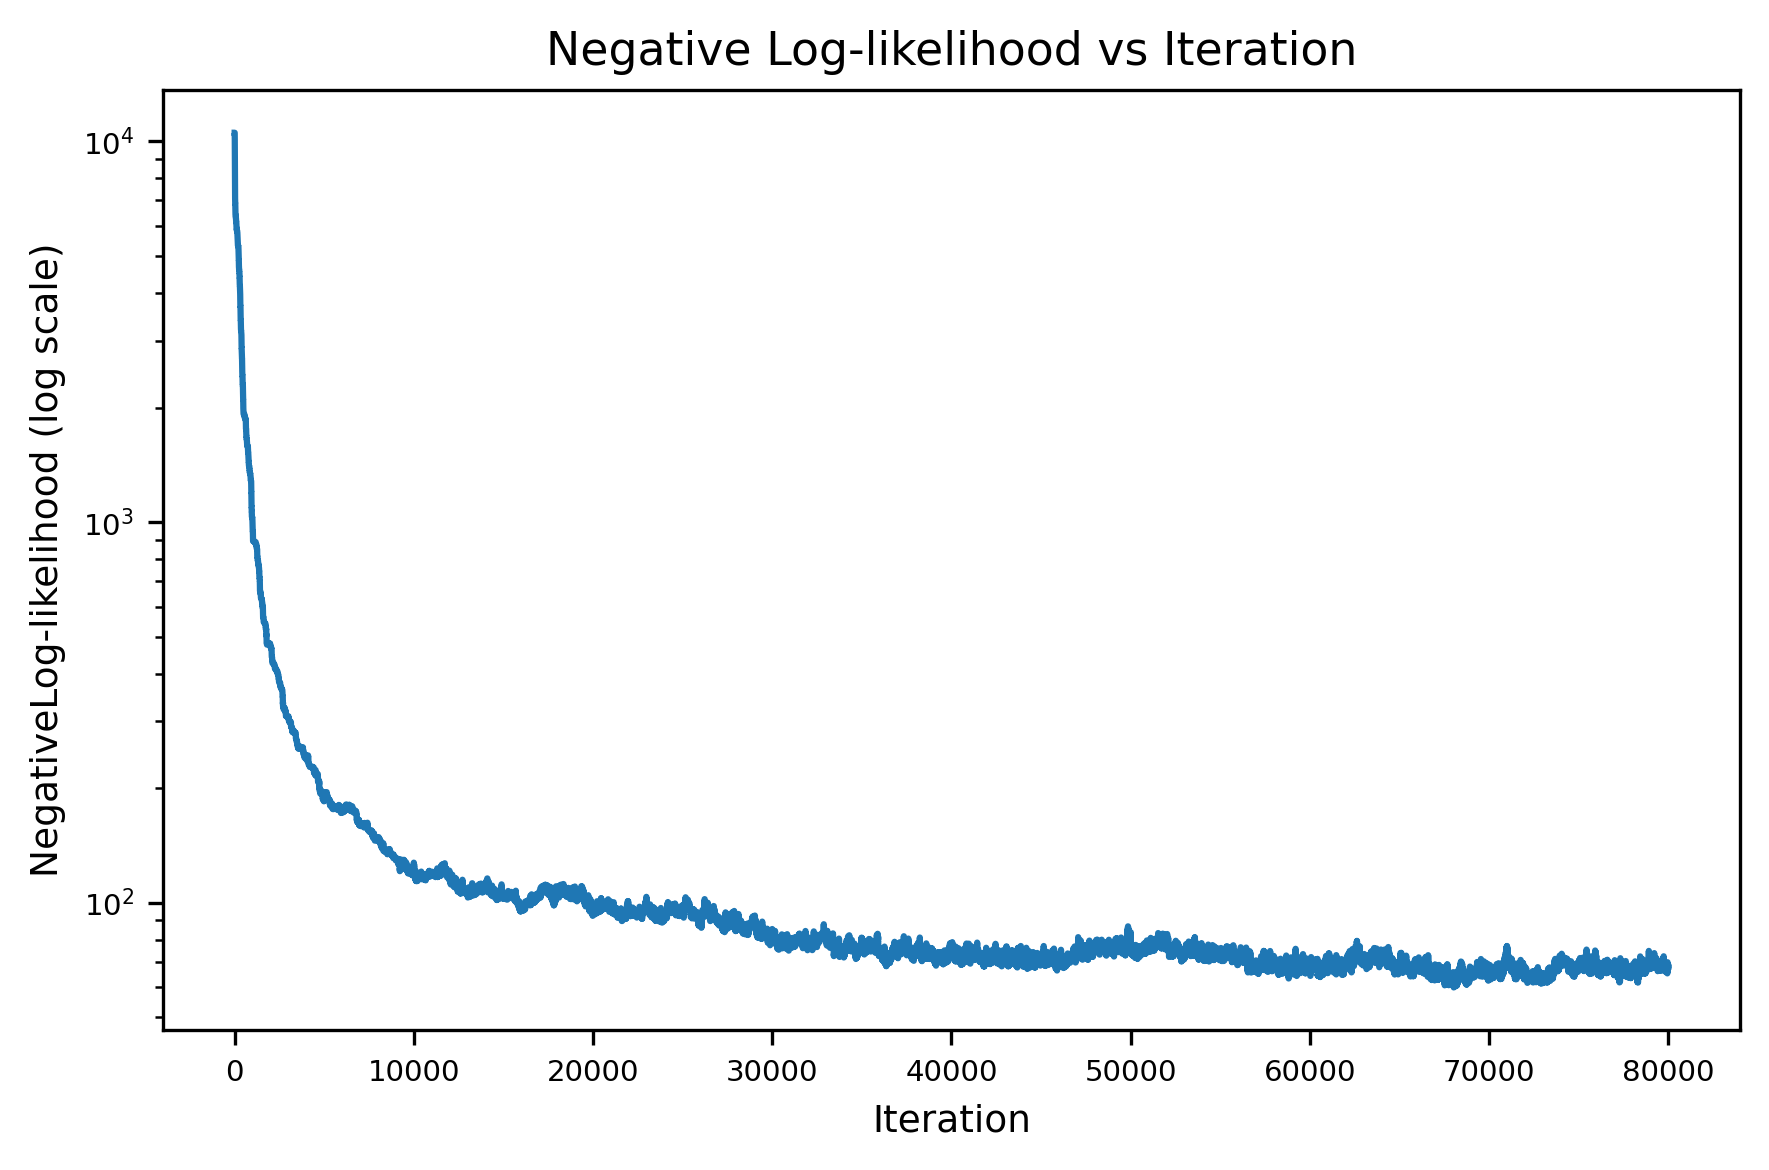

In [55]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=300)
ax.plot(-np.array(loss_evolution))
ax.set_yscale('log')
ax.set_title("Negative Log-likelihood vs Iteration", fontsize=11, loc='center', pad=6)
ax.set_xlabel("Iteration", fontsize=9)
ax.set_ylabel("NegativeLog-likelihood (log scale)", fontsize=9)
ax.tick_params(labelsize=7)
plt.tight_layout()
# plt.savefig('figures_for_report/loss_curve.png', bbox_inches='tight', dpi=300)
plt.show()

<class 'torch.Tensor'>
torch.Size([1, 1, 128, 128])


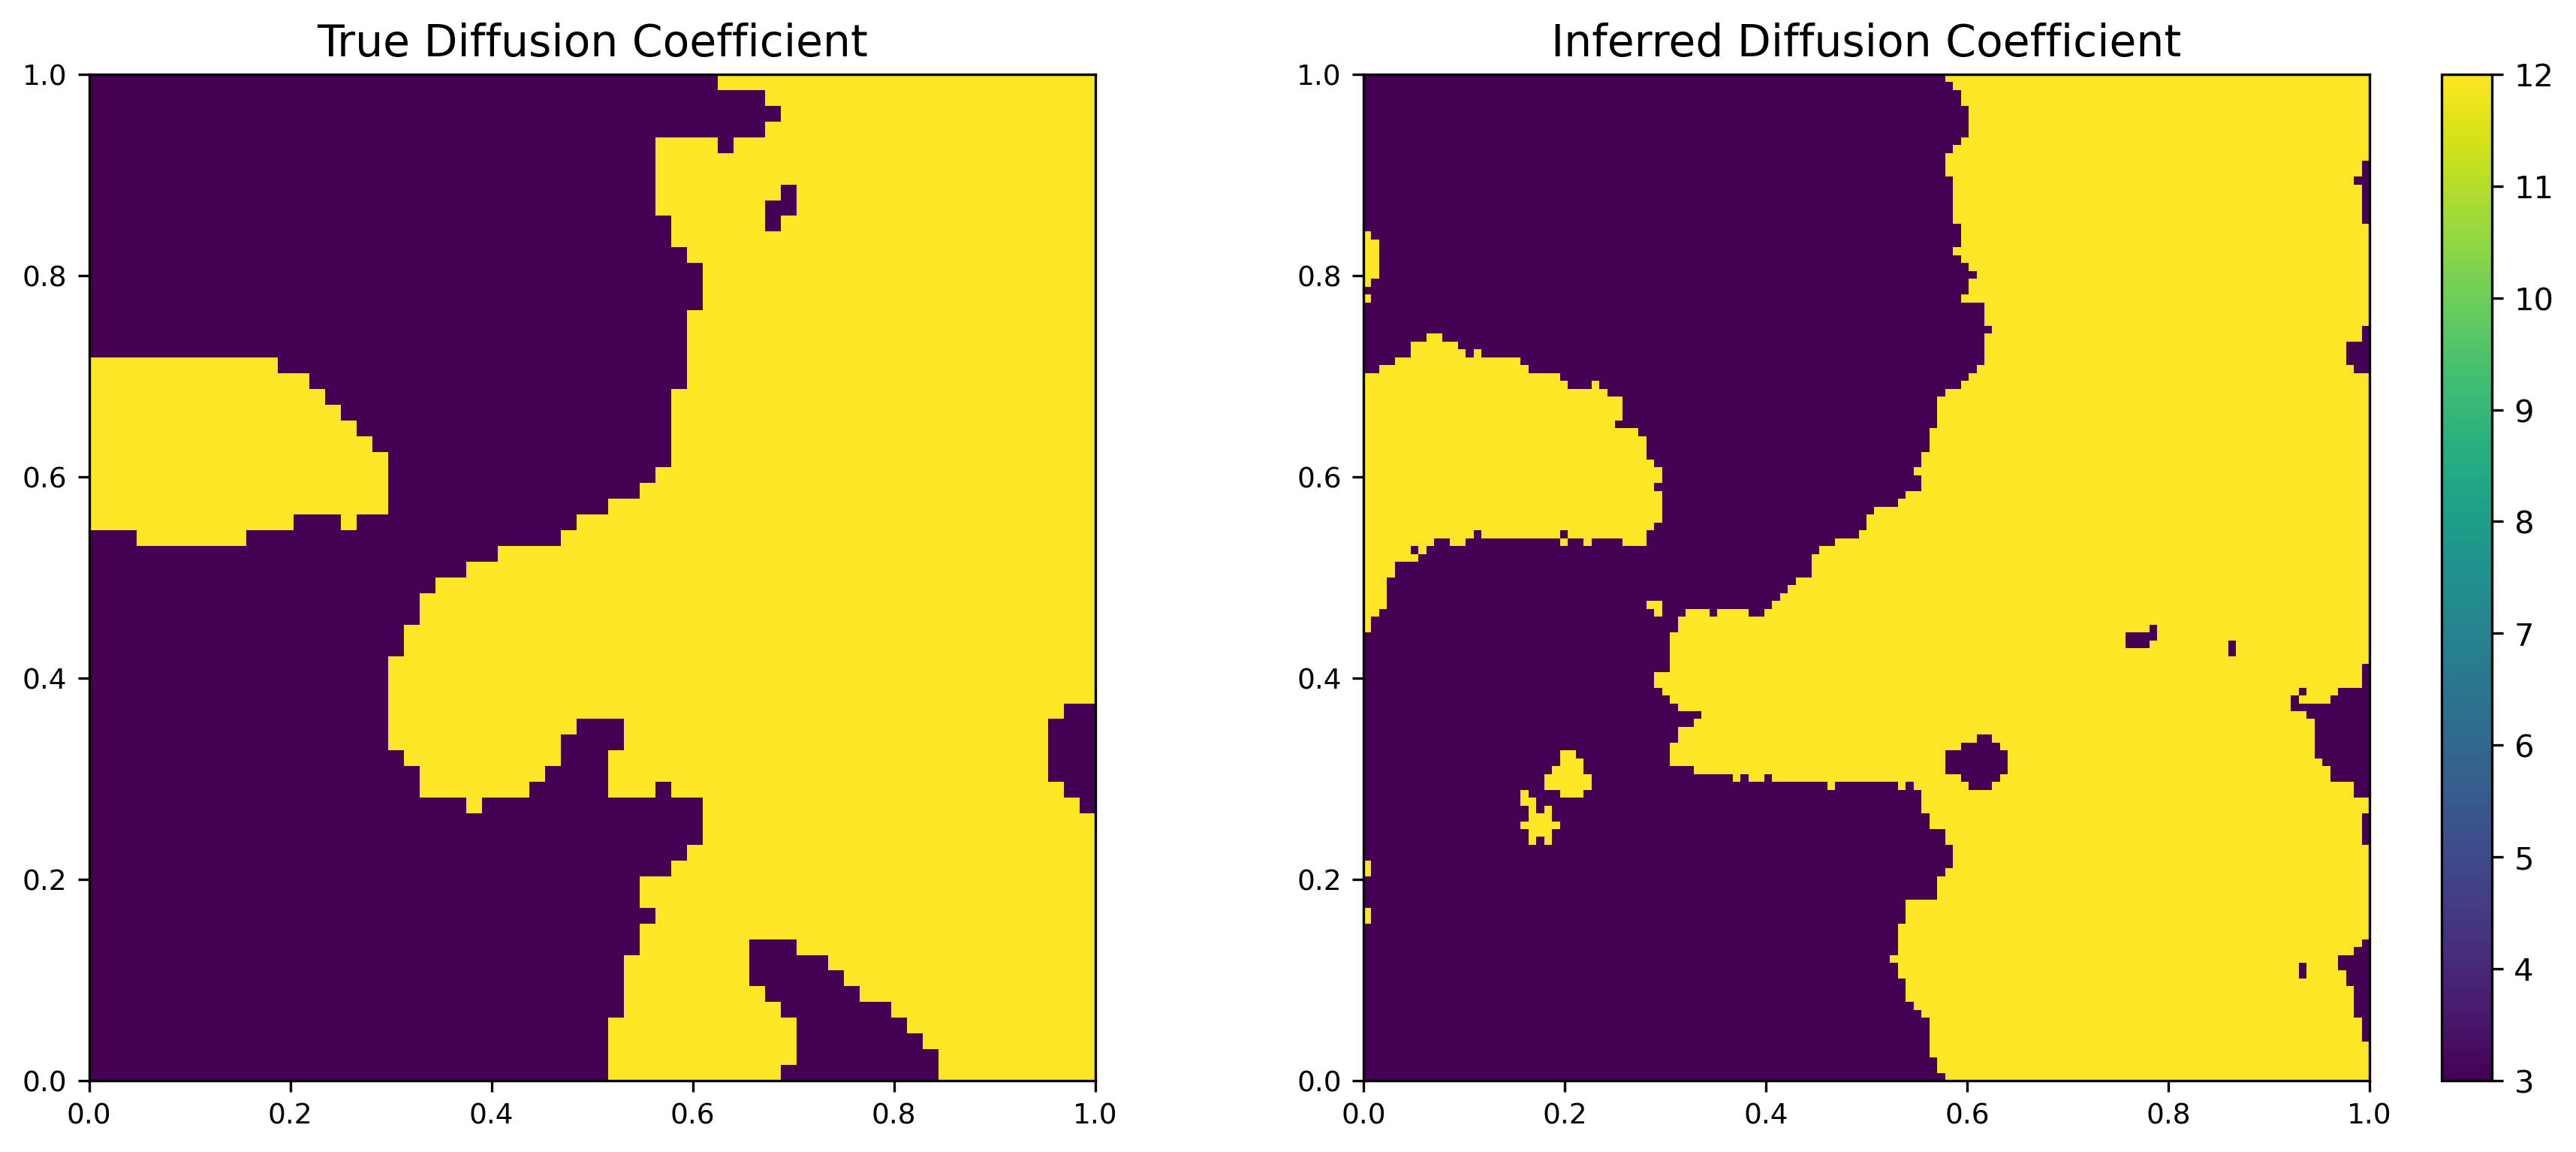

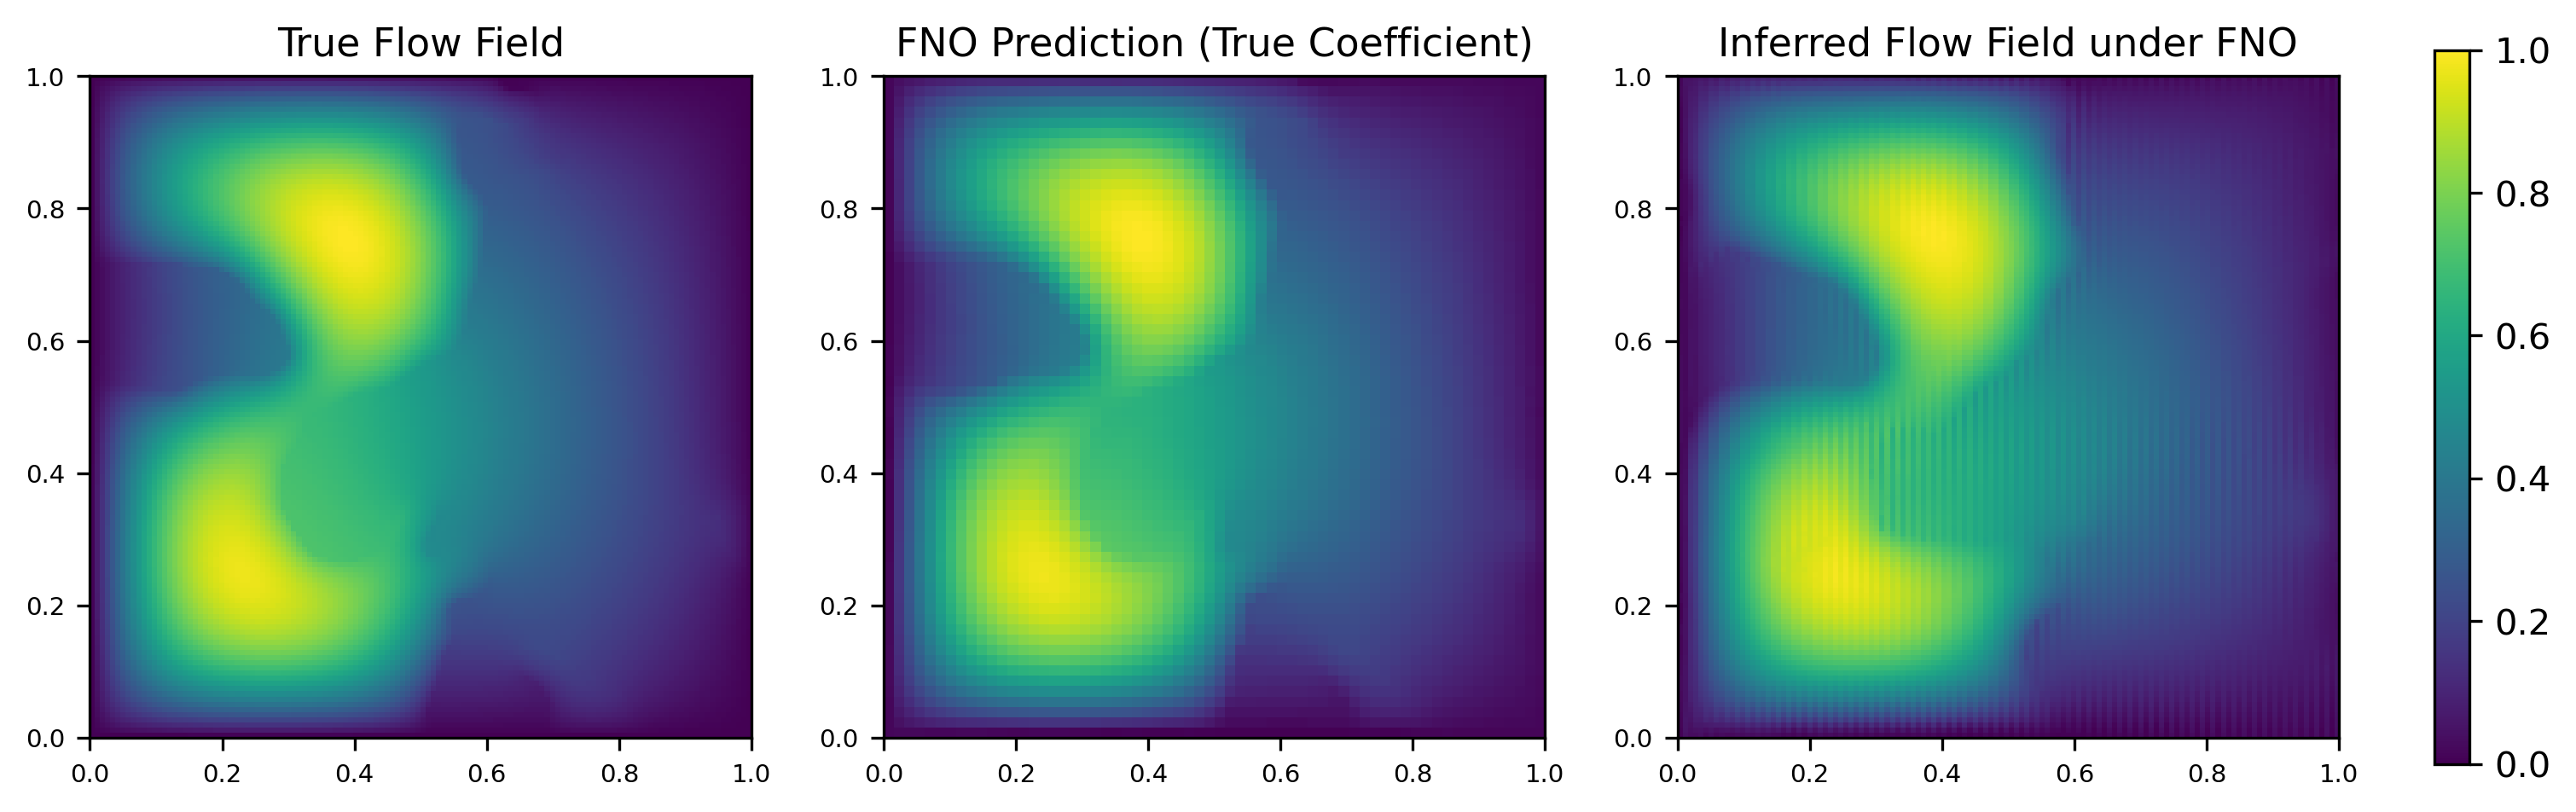

In [56]:
with torch.no_grad():
    forwards = model(true_field[0,0].unsqueeze(0).unsqueeze(0).to(device))

# Compute predicted solution
average_predicted_field = T_push(torch.from_numpy(np.mean(theta_evolution[-10000::1000], axis=0)), tau=-1, boundary=7.5).unsqueeze(0).unsqueeze(0)
print(type(theta_0_tensor))
print(average_predicted_field.shape)
with torch.no_grad():
    predicted_solution = model(average_predicted_field.to(device)).cpu().numpy()[0, 0]

average_predicted_field = average_predicted_field.squeeze(0).squeeze(0)

# FNO forward pass on true field
fno_prediction = forwards.cpu().numpy()[0, 0]

# ----------------------
# First figure (top row)
# ----------------------
fig1, axs1 = plt.subplots(1, 2, figsize=(12, 5), dpi=300, constrained_layout=True)
fields1 = [
    true_field.cpu().numpy()[0, 0],
    average_predicted_field,
]
titles1 = [
    "True Diffusion Coefficient",
    "Inferred Diffusion Coefficient",
]
for ax, field, title in zip(axs1, fields1, titles1):
    im = ax.imshow(field, extent=[0, 1, 0, 1], origin='lower')
    ax.set_title(title, fontsize=14, loc='center', pad=6)
    ax.tick_params(labelsize=9)

fig1.colorbar(im, ax=axs1, fraction=0.03, pad=0.02, shrink=1.0, aspect=20)
# plt.savefig('figures_for_report/single_true_vs_inferred_coefficients.png', bbox_inches='tight', dpi=300)
plt.show()

# ----------------------
# Second figure (bottom row)
# ----------------------
fig2, axs2 = plt.subplots(1, 3, figsize=(12, 4), dpi=300)

fields2 = [
    true_observations.cpu().numpy()[0, 0],
    fno_prediction,
    predicted_solution,
]

titles2 = [
    "True Flow Field",
    "FNO Prediction (True Coefficient)",
    "Inferred Flow Field under FNO",
]

from matplotlib.colors import Normalize

for ax, field, title in zip(axs2, fields2, titles2):
    field_norm = (field - field.min()) / (field.max() - field.min())
    im = ax.imshow(field_norm, extent=[0, 1, 0, 1], origin='lower', vmin=0, vmax=1)
    ax.set_title(title, fontsize=11, loc='center', pad=6)
    ax.tick_params(labelsize=7)

fig2.colorbar(im, ax=axs2, fraction=0.015, pad=0.04)
# plt.savefig('figures_for_report/single_true_vs_inferred_flows.png', bbox_inches='tight', dpi=300)
plt.show()

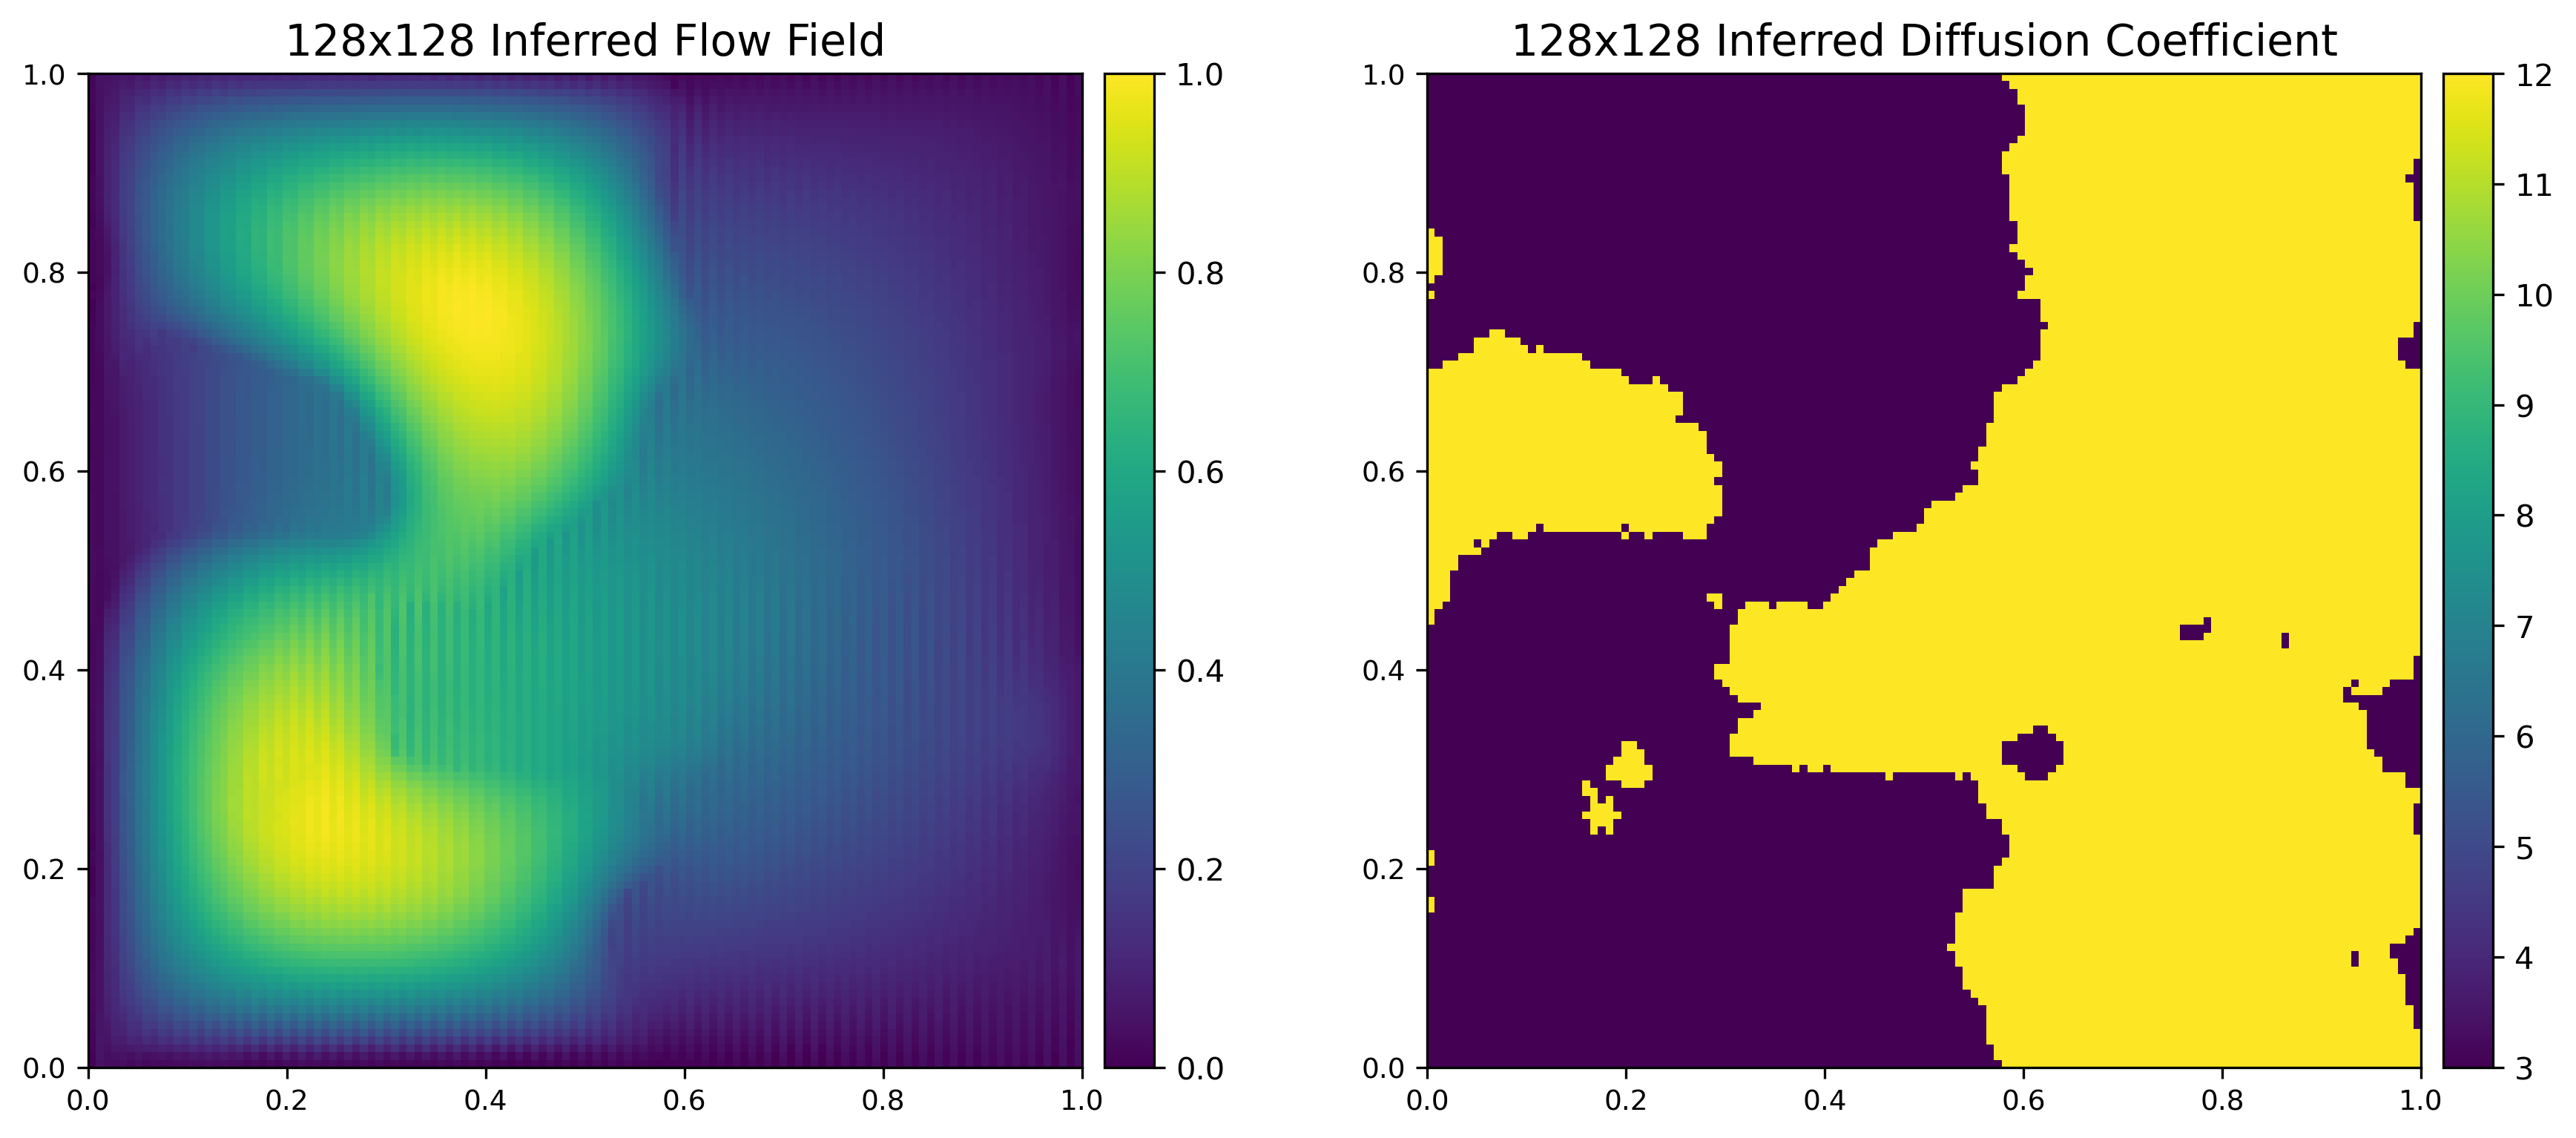

In [57]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, axs = plt.subplots(1, 2, figsize=(12, 5), dpi=300, constrained_layout=True)

# Left: "Inferred Flow Field" from fig2 (normalised)
flow_field = predicted_solution
flow_field_norm = (flow_field - flow_field.min()) / (flow_field.max() - flow_field.min())
im0 = axs[0].imshow(flow_field_norm, extent=[0, 1, 0, 1], origin='lower', vmin=0, vmax=1)
axs[0].set_title("128x128 Inferred Flow Field", fontsize=14, loc='center', pad=6)
axs[0].tick_params(labelsize=9)
divider0 = make_axes_locatable(axs[0])
cax0 = divider0.append_axes("right", size="5%", pad=0.1)
fig.colorbar(im0, cax=cax0)

# Right: "Inferred Diffusion Coefficient" from fig1
diff_field = average_predicted_field
im1 = axs[1].imshow(diff_field, extent=[0, 1, 0, 1], origin='lower')
axs[1].set_title("128x128 Inferred Diffusion Coefficient", fontsize=14, loc='center', pad=6)
axs[1].tick_params(labelsize=9)
divider1 = make_axes_locatable(axs[1])
cax1 = divider1.append_axes("right", size="5%", pad=0.1)
fig.colorbar(im1, cax=cax1)

plt.savefig('figures_for_report/super_res_combined_inferred.png', bbox_inches='tight', dpi=300)
plt.show()

In [58]:
# FNO error on the true coefficient -- this is your best possible NLL
true_field = dataset.test_dbs[128].x[0, 0].unsqueeze(0).unsqueeze(0)  # super-resolution task, so get the 128x128 true field
theta_true_tensor = torch.tensor(true_field.cpu().numpy()[0, 0], dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
ll_true = log_likelihood(theta_true_tensor, true_observations, model, sigma=sigma)
print(f"NLL with true coefficient: {ll_true:.2f}")
print(f"NLL of MCMC solution:      {ll_current:.2f}")

NLL with true coefficient: -49.80
NLL of MCMC solution:      -67.98


In [59]:
# MCMC solution
pred = torch.tensor(predicted_solution).unsqueeze(0).unsqueeze(0)
pred_norm = (pred - pred.min()) / (pred.max() - pred.min())

obs = true_observations.cpu()[0, 0]
obs_norm = (obs - obs.min()) / (obs.max() - obs.min())
obs_norm = obs_norm.unsqueeze(0).unsqueeze(0)

h1_pred = h1loss(pred_norm, obs_norm)
l2_pred = l2loss(pred_norm, obs_norm)
print(f"H1 Loss of MCMC solution: {h1_pred.item():.4f}")
print(f"L2 Loss of MCMC solution: {l2_pred.item():.4f}")

# True coefficient baseline
with torch.no_grad():
    FNO_predicted_true = model(theta_true_tensor).cpu()[0, 0]

fno_norm = (FNO_predicted_true - FNO_predicted_true.min()) / (FNO_predicted_true.max() - FNO_predicted_true.min())
fno_norm = fno_norm.unsqueeze(0).unsqueeze(0)

h1_true = h1loss(fno_norm, obs_norm)
l2_true = l2loss(fno_norm, obs_norm)
print(f"H1 Loss of true solution: {h1_true.item():.4f}")
print(f"L2 Loss of true solution: {l2_true.item():.4f}")

H1 Loss of MCMC solution: 0.2951
L2 Loss of MCMC solution: 0.0528
H1 Loss of true solution: 0.1964
L2 Loss of true solution: 0.0606


In [60]:
# Estimate a reasonable sigma from the FNO's own error on the true field
with torch.no_grad():
    fno_pred = model(theta_true_tensor)
    # unnormalise...
    residuals = (true_observations - fno_pred[0,0])
    print(f"Suggested sigma: {residuals.std().item():.4f}")

Suggested sigma: 0.5069


Text(0.5, 1.0, 'Mean absolute change per step')

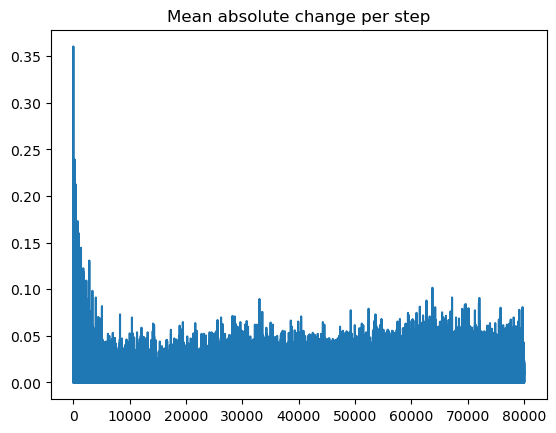

In [61]:
# Plot how much the chain moves each step
diffs = [np.mean(np.abs(theta_evolution[i] - theta_evolution[i-1])) 
         for i in range(1, len(theta_evolution))]
plt.plot(diffs)
plt.title("Mean absolute change per step")